In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("Obesity prediction.csv")

In [5]:
df

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [6]:
def check_df(dataframe):
  print("################### Shape ##################")
  print(dataframe.shape)
  print("################### Types ##################")
  print(dataframe.info())
  print("################### Head ##################")
  print(dataframe.head())
  print("################### Tail ##################")
  print(dataframe.tail())
  print("################### NA ##################")
  print(dataframe.isnull().sum())
  print("################### Quantiles ##################")
  print(dataframe.describe([0, 0.25, 0.50, 0.75, 0.99, 1]).T)

check_df(df)

################### Shape ##################
(2111, 17)
################### Types ##################
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 n

Boş değerimiz yok ancak ml problemimiz numerik değerler istedği için encode ve standartlaştırma işlemi yapacağız. Bu yüzden önce kategorik ve numerik değişkenleri ayırmalıyız.

In [8]:
#Değişken türlerini belirliyoruz.
def grab_col_names(dataframe, cat_th=10, car_th=20):
  cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
  num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < cat_th and
                 dataframe[col].dtypes != "O"]
  cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > car_th and
                 dataframe[col].dtypes == "O"]

  cat_cols = cat_cols + num_but_cat
  cat_cols = [col for col in cat_cols if col not in cat_but_car]

  num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O" ]
  num_cols = [col for col in num_cols if col not in num_but_cat]

  print(f"Observations: {dataframe.shape[0]}")
  print(f"Variables: {dataframe.shape[1]}")
  print(f'cat_cols: {len(cat_cols)}')
  print(f'num_cols: {len(num_cols)}')
  print(f'cat_but_car: {len(cat_but_car)}')
  print(f'num_but_cat: {len(num_but_cat)}')
  return cat_cols, num_cols,num_but_cat

cat_cols, num_cols, cat_but_car = grab_col_names(df)

Observations: 2111
Variables: 17
cat_cols: 9
num_cols: 8
cat_but_car: 0
num_but_cat: 0


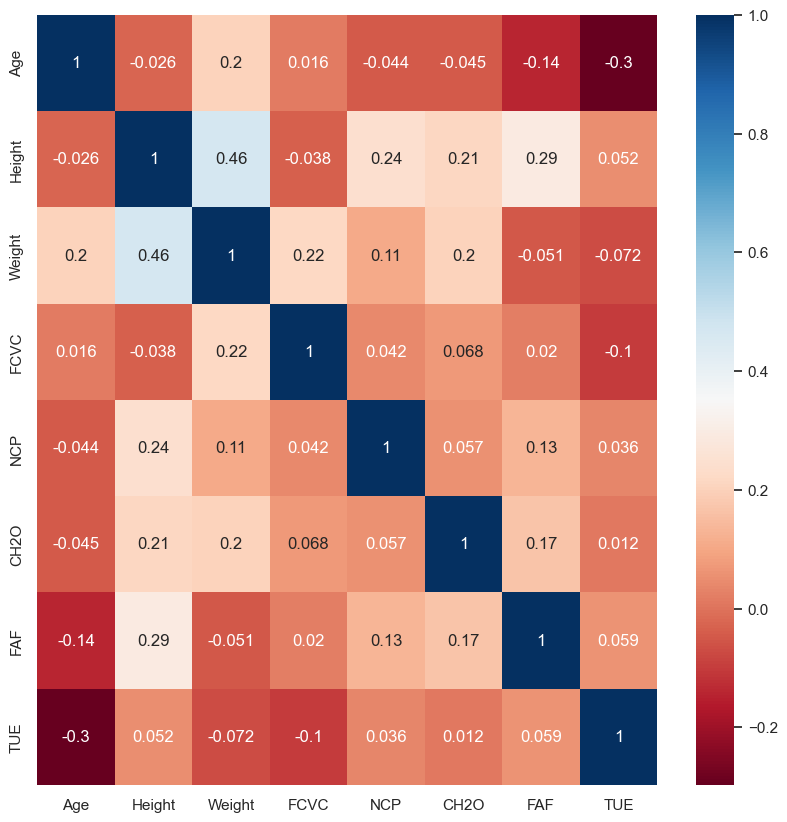

In [9]:
#Korelasyon analizi
corr = df[num_cols].corr()

sns.set(rc={'figure.figsize': (10,10)})
sns.heatmap(corr, cmap="RdBu", annot=True)
plt.show()

**One Hot Encoder**

In [11]:
cat_cols = [col for col in cat_cols if col not in ["Obesity"]]

def one_hot_encoder(dataframe, categorical_cols, drop_first=False):
    dataframe = pd.get_dummies(dataframe, columns=categorical_cols, drop_first=drop_first)
    return dataframe

df = one_hot_encoder(df, cat_cols, drop_first=True)

**Scale**

In [13]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head(5)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Obesity,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,Normal_Weight,False,...,False,False,False,False,False,True,False,False,True,False
1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,Normal_Weight,False,...,False,True,True,False,True,False,False,False,True,False
2,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,Normal_Weight,True,...,False,False,False,True,False,False,False,False,True,False
3,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,Overweight_Level_I,True,...,False,False,False,True,False,False,False,False,False,True
4,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,Overweight_Level_II,True,...,False,False,False,False,True,False,False,False,True,False


In [14]:
y = df["Obesity"]
X = df.drop(["Obesity"], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models =  svm.SVC()
# {"LR:" : LogisticRegression(),
#           "KNN:": KNeighborsClassifier(n_neighbors=5),
#           "SVM:": svm.SVC()}

In [15]:
# for model_name, model in models.items():
#     model.fit(X_train,y_train)
#     y_pred=model.predict(X_test)
#     accuracy=accuracy_score(y_test,y_pred)
#     print(f"{model_name}")
#     print(f"{accuracy*100}")
#     print(classification_report(y_test,y_pred))

In [16]:
# from sklearn.decomposition import PCA

# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X)

In [17]:
X_train

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_yes,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
162,-0.522124,-0.768388,-1.015318,1.088342,0.404153,-0.013073,1.163820,-1.080625,False,True,...,False,True,False,False,True,False,False,False,True,False
2001,-0.533953,0.545156,1.796170,1.088342,0.404153,1.435437,0.553418,0.200030,False,True,...,False,False,False,False,True,False,False,False,True,False
1435,-0.222692,-0.428400,-0.152388,-2.276674,-1.710184,1.236246,-1.037118,1.645266,False,True,...,False,False,False,False,True,False,False,False,True,False
649,-0.390041,-1.218139,-1.617340,1.088342,-1.272151,0.884935,0.104145,-1.080625,False,False,...,False,False,False,False,False,True,False,False,True,False
1280,0.265136,1.178403,0.743025,1.088342,0.404153,1.387317,0.944295,0.036711,True,True,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,1.257405,0.571152,1.279847,1.027083,0.404153,0.851855,-0.064653,1.119226,True,True,...,False,False,False,False,True,False,False,False,False,False
1095,-0.206889,0.185497,-0.187745,-0.785019,-1.229118,-0.991769,-0.143904,0.581680,True,True,...,False,False,False,False,True,False,False,False,True,False
1130,-0.208489,-0.553986,-0.251521,-0.785019,0.404153,-0.013073,-1.015273,2.204618,False,True,...,False,False,False,False,False,True,False,False,True,False
1294,-0.206889,-0.788028,-0.079743,-0.675077,0.355306,0.004218,-0.187254,-0.044351,False,True,...,False,False,False,False,False,True,False,False,True,False


In [18]:
# X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)
svm_model = svm.SVC().fit(X_train, y_train)
y_pred_pca = svm_model.predict(X_test)

# print("Classification :")
# print(classification_report(y_test_pca,y_pred_pca))

In [19]:
X.replace([True,False],[1,0],inplace=True)

In [20]:
import pickle

In [21]:
filename = 'obesity_model.sav'
pickle.dump(svm_model, open(filename, 'wb'))

In [22]:
# loading the saved model
loaded_model = pickle.load(open('obesity_model.sav', 'rb'))

In [23]:
X.iloc[50]

Age                            -0.522124
Height                         -0.982790
Weight                         -1.225362
FCVC                            1.088342
NCP                             0.404153
CH2O                            1.618759
FAF                            -1.188039
TUE                             0.561997
Gender_Male                     0.000000
family_history_yes              1.000000
FAVC_yes                        1.000000
CAEC_Frequently                 0.000000
CAEC_Sometimes                  1.000000
CAEC_no                         0.000000
SMOKE_yes                       0.000000
SCC_yes                         0.000000
CALC_Frequently                 0.000000
CALC_Sometimes                  1.000000
CALC_no                         0.000000
MTRANS_Bike                     0.000000
MTRANS_Motorbike                0.000000
MTRANS_Public_Transportation    0.000000
MTRANS_Walking                  1.000000
Name: 50, dtype: float64

In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

input_data = (scaler.fit_transform([[52,1.94,1.16,0.40,1.61,2.33,1.08,0,1,0,0,1,0,1,1,0,1,0,0,0,1,0,1]]))

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
# input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = loaded_model.predict(input_data_as_numpy_array)
print(prediction)

if (prediction[0] == 0):
  print('The person has not obesity')
else:
  print('The person has obesity')

['Overweight_Level_II']
The person has obesity


In [25]:
for column in X.columns:
  print(column)

Age
Height
Weight
FCVC
NCP
CH2O
FAF
TUE
Gender_Male
family_history_yes
FAVC_yes
CAEC_Frequently
CAEC_Sometimes
CAEC_no
SMOKE_yes
SCC_yes
CALC_Frequently
CALC_Sometimes
CALC_no
MTRANS_Bike
MTRANS_Motorbike
MTRANS_Public_Transportation
MTRANS_Walking


In [48]:
pd.set_option("display.max_columns", None)
X.iloc[1:100]

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_yes,FAVC_yes,CAEC_Frequently,CAEC_Sometimes,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,0,1,0,0,1,0,1,1,0,1,0,0,0,1,0
2,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,1,1,0,0,1,0,0,0,1,0,0,0,0,1,0
3,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1
4,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0
5,0.738817,-0.875589,-1.282647,-0.785019,0.404153,-0.013073,-1.188039,-1.080625,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.265964,-0.017981,-0.633419,1.088342,-2.167023,-0.013073,1.163820,-1.080625,1,1,0,1,0,0,0,0,1,0,0,0,0,1,0
96,-0.206889,-0.446785,-1.015318,-0.785019,0.404153,-0.013073,2.339750,-1.080625,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0
97,-0.522124,-1.947599,-1.702735,1.088342,-2.167023,-1.644905,-1.188039,-1.080625,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0
98,-0.522124,-1.947599,-1.702735,1.088342,-2.167023,-1.644905,-1.188039,-1.080625,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0


In [62]:
X[]

array(list(['I', 'am', 'a', 'python', 'Dev']), dtype=object)